In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/NLP_Project_Final'

SAVE_RS = os.path.join(BASE_DIR, 'Results')
os.makedirs(SAVE_RS, exist_ok=True)

MODEL_DIR = os.path.join(BASE_DIR, 'Model')
DATA_DIR = os.path.join(MODEL_DIR, 'SplitData')
WEIGHTS_DIR = os.path.join(MODEL_DIR, 'Weights')

os.makedirs(WEIGHTS_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_data.csv'))
val_df = pd.read_csv(os.path.join(DATA_DIR, 'val_data.csv'))

X_train, y_train = train_df['text'].astype(str), train_df['label']
X_val, y_val = val_df['text'].astype(str), val_df['label']

print(f"    - Training samples: {len(X_train)}")
print(f"    - Validation samples: {len(X_val)}")

    - Training samples: 31940
    - Validation samples: 3992


In [ ]:
MAX_VOCAB = 25000
MAX_LEN = 311

vectorizer = layers.TextVectorization(max_tokens=MAX_VOCAB, output_sequence_length=MAX_LEN)
vectorizer.adapt(X_train.values)

print(f">>> [VECTORIZER] Vocabulary adapted with {MAX_VOCAB} tokens.")

>>> [VECTORIZER] Vocabulary adapted with 25000 tokens.


In [ ]:
def prepare_dataset(X, y, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices((X.values, y.values))
    ds = ds.shuffle(buffer_size=len(X)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = prepare_dataset(X_train, y_train)
val_ds = prepare_dataset(X_val, y_val)

In [ ]:
def build_bilstm_model():
    inputs = layers.Input(shape=(1,), dtype="string")
    x = vectorizer(inputs)
    x = layers.Embedding(MAX_VOCAB, 128, mask_zero=True)(x)
    x = layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2))(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(4, activation="softmax")(x)
    return Model(inputs, outputs)

model_lstm = build_bilstm_model()
model_lstm.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_lstm.summary()

ckpt_path = os.path.join(WEIGHTS_DIR, 'bilstm_best_weights.weights.h5')
checkpoint = ModelCheckpoint(
    ckpt_path, monitor='val_accuracy', save_best_only=True,
    save_weights_only=True, mode='max', verbose=1
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 311)       │          0 │ input_layer[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 311, 128)  │  3,200,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 311)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,307,332 (12.62 MB)

 Trainable params: 3,307,332 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("\n>>> [TRAINING] Bi-LSTM is starting...")
history = model_lstm.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop]
)


>>> [TRAINING] Bi-LSTM is starting...
Epoch 1/10
999/999 ━━━━━━━━━━━━━━━━━━━━ 0s 985ms/step - accuracy: 0.5691 - loss: 0.9064
Epoch 1: val_accuracy improved from -inf to 0.87675, saving model to /content/drive/MyDrive/NLP_Project_Final/Model/Weights/bilstm_best_weights.weights.h5
999/999 ━━━━━━━━━━━━━━━━━━━━ 1023s 1s/step - accuracy: 0.5692 - loss: 0.9062 - val_accuracy: 0.8768 - val_loss: 0.3395
Epoch 2/10
999/999 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8726 - loss: 0.3924
Epoch 2: val_accuracy improved from 0.87675 to 0.93587, saving model to /content/drive/MyDrive/NLP_Project_Final/Model/Weights/bilstm_best_weights.weights.h5
999/999 ━━━━━━━━━━━━━━━━━━━━ 1043s 1s/step - accuracy: 0.8726 - loss: 0.3924 - val_accuracy: 0.9359 - val_loss: 0.2374
Epoch 3/10
999/999 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9288 - loss: 0.2543
Epoch 3: val_accuracy improved from 0.93587 to 0.94639, saving model to /content/drive/MyDrive/NLP_Project_Final/Model/Weights/bilstm_best_weights.weigh


>>> [SAVED] Learning curves saved to: /content/drive/MyDrive/NLP_Project_Final/Results/bilstm_learning_curves.png


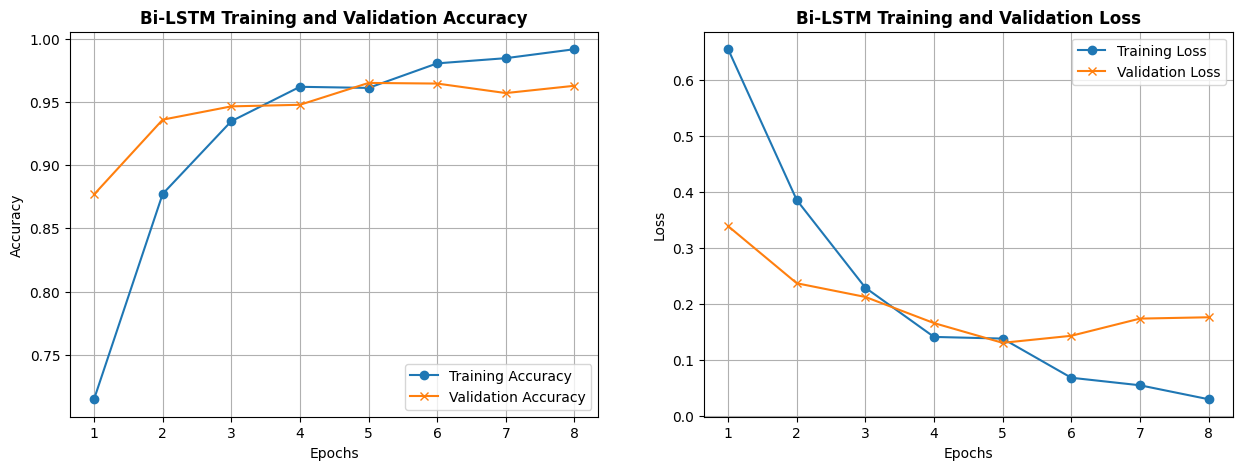

In [ ]:
def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
    plt.title('Bi-LSTM Training and Validation Accuracy', fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
    plt.title('Bi-LSTM Training and Validation Loss', fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plot_path = os.path.join(SAVE_RS, 'bilstm_learning_curves.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\n>>> [SAVED] Learning curves saved to: {plot_path}")
    plt.show()

plot_learning_curves(history)

In [ ]:
final_model_path = os.path.join(WEIGHTS_DIR, 'bilstm_last_full_model.keras')
model_lstm.save(final_model_path)
print(f"\n>>> [SUCCESS] Bi-LSTM process complete. All assets saved in: {WEIGHTS_DIR}")


>>> [SUCCESS] Bi-LSTM process complete. All assets saved in: /content/drive/MyDrive/NLP_Project_Final/Model/Weights


In [ ]:
import numpy as np

label_names = ['Case Report', 'Meta-Analysis', 'Observational Study', 'Randomized Controlled Trial']

def quick_test_bilstm(text, model):
    input_data = np.array([str(text)], dtype=object)

    probs = model.predict(input_data, verbose=0)[0]
    idx = np.argmax(probs)

    print(f"\nSnippet: {text[:100]}...")
    print(f"==> PREDICTED: [{label_names[idx]}] ({probs[idx]*100:.2f}% confidence)")

    for i, label in enumerate(label_names):
        print(f"    - {label}: {probs[i]*100:.2f}%")

doan_van_1 = "We conducted a double-blind, placebo-controlled trial to evaluate the efficacy of the new vaccine. A total of 1000 healthy volunteers were randomly assigned in a 1:1 ratio to receive either the vaccine or a placebo. The primary endpoint was the incidence of infection over a 12-month period."
doan_van_2 = "A 45-year-old male patient presented to the emergency department with a two-day history of severe lower abdominal pain and fever. Computed tomography revealed a rare appendiceal tumor. The patient underwent an emergency appendectomy and recovered uneventfully. This case highlights the importance of early imaging in atypical presentations."
doan_van_3 = "This retrospective cohort study aimed to investigate the long-term effects of smoking on lung capacity. We analyzed the medical records of 5,000 patients over a 10-year follow-up period. Logistic regression models were used to adjust for confounding variables. The results showed a significant decline in lung function among heavy smokers compared to non-smokers."

print(">>> [TESTING] Real-time inference with Bi-LSTM (Best Weights):")
for i, txt in enumerate([doan_van_1, doan_van_2, doan_van_3]):
    print(f"\n--- Sample {i+1} ---")
    quick_test_bilstm(txt, model_lstm)

>>> [TESTING] Real-time inference with Bi-LSTM (Best Weights):

--- Sample 1 ---

Snippet: We conducted a double-blind, placebo-controlled trial to evaluate the efficacy of the new vaccine. A...
==> PREDICTED: [Randomized Controlled Trial] (99.93% confidence)
    - Case Report: 0.01%
    - Meta-Analysis: 0.02%
    - Observational Study: 0.04%
    - Randomized Controlled Trial: 99.93%

--- Sample 2 ---

Snippet: A 45-year-old male patient presented to the emergency department with a two-day history of severe lo...
==> PREDICTED: [Case Report] (100.00% confidence)
    - Case Report: 100.00%
    - Meta-Analysis: 0.00%
    - Observational Study: 0.00%
    - Randomized Controlled Trial: 0.00%

--- Sample 3 ---

Snippet: This retrospective cohort study aimed to investigate the long-term effects of smoking on lung capaci...
==> PREDICTED: [Observational Study] (99.94% confidence)
    - Case Report: 0.01%
    - Meta-Analysis: 0.04%
    - Observational Study: 99.94%
    - Randomized Controlled 